In [1]:
import pandas as pd

df = pd.read_csv('Movies_Dataset_Clustering_Experiment.csv', low_memory=False)

First, I analyze the distribution of words in the keywords, title, tagline and overview columns. As we can see, very few words occur more than a few times each.

In [12]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def remove_stopwords(text):
    words = text.split()
    return " ".join([w for w in words if w.lower() not in ENGLISH_STOP_WORDS])

def remove_duplicates(text):
    return " ".join(set(text.split()))

def get_word_counts(dataframe):
    return (
        dataframe
        .dropna()
        .str.lower()
        .str.findall(r'\b\w{2,}\b')   # exclude 1-letter words
        .explode()
        .value_counts()
    )

keywords_list = df['keywords'].dropna()
overview_list = df['overview'].fillna('').apply(remove_stopwords).apply(remove_duplicates)
title_list = df['title'].fillna('').apply(remove_stopwords).apply(remove_duplicates)
tagline_list = df['tagline'].fillna('').apply(remove_stopwords).apply(remove_duplicates)

word_counts_keywords = get_word_counts(keywords_list)
word_counts_overview = get_word_counts(overview_list)
word_counts_title = get_word_counts(title_list)
word_counts_tagline = get_word_counts(tagline_list)

word_counts = {
    'Keywords': word_counts_keywords,
    'Overview': word_counts_overview,
    'Title': word_counts_title,
    'Tagline': word_counts_tagline
}

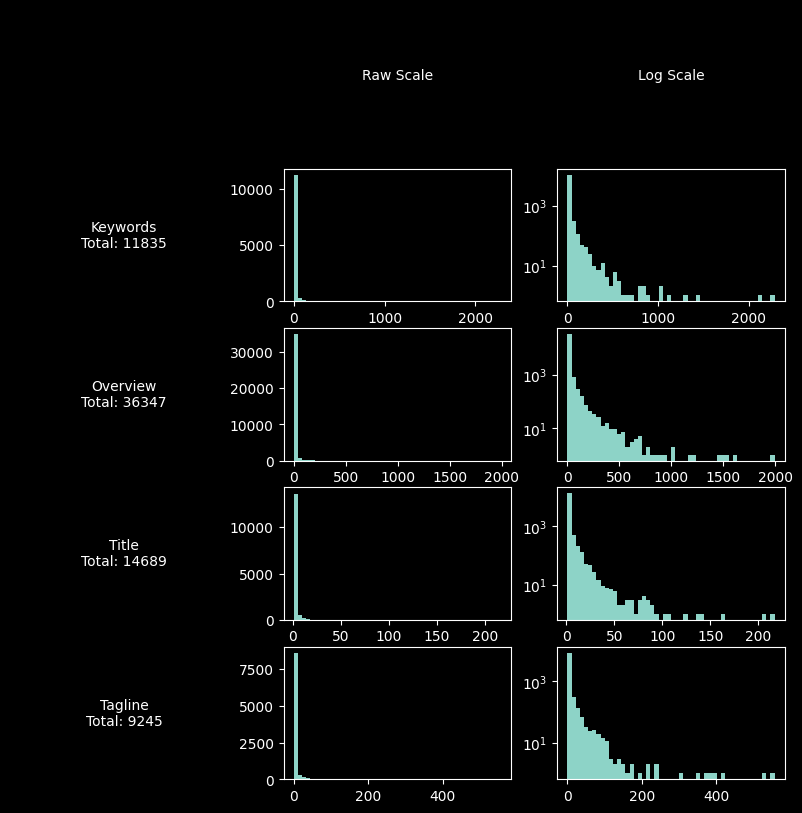

In [13]:
import matplotlib.pyplot as plt

col_labels = ["Raw Scale", "Log Scale"]
row_labels = []
totals = []
data = []

fig, axes = plt.subplots(5, 3, figsize=(10, 10))

for entry in word_counts:
    row_labels.append(entry)
    totals.append(len(word_counts[entry]))
    data.append([word_counts[entry], word_counts[entry]])

for i in range(5):
    for j in range(3):
        ax = axes[i, j]

        # Top-left corner (empty)
        if i == 0 and j == 0:
            ax.axis('off')

        # Top row (column labels)
        elif i == 0:
            ax.text(0.5, 0.5, col_labels[j-1],
                    ha='center', va='center')
            ax.axis('off')

        # Left column (row labels + totals)
        elif j == 0:
            label = f"{row_labels[i-1]}\nTotal: {totals[i-1]}"
            ax.text(0.5, 0.5, label,
                    ha='center', va='center')
            ax.axis('off')

        # Raw scale column
        elif j == 1:
            ax.hist(data[i-1][j-1], bins=50)

        # Log scale column
        else:
            ax.set_yscale('log')
            ax.hist(data[i-1][j-1], bins=50)

Common sense would suggest that there will be a lot of crossover between the keywords and overview categories. Here I investigate what percentage of overlap there is for every entry. As we can see however, there is consistently very little (less than 20% overlap).

In [14]:
import re

def separate_string(input_string, seperator):
    return input_string.split(seperator)

keywords_separated = keywords_list.apply(separate_string, '-')
keywords_separated = keywords_separated.dropna()
keywords_separated = [[word for word in sublist if len(word) > 1] for sublist in keywords_separated]

def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

overviews_separated = overview_list.apply(tokenize)
overviews_separated = overviews_separated.dropna()
overviews_separated = [[word for word in sublist if len(word) > 1] for sublist in overviews_separated]

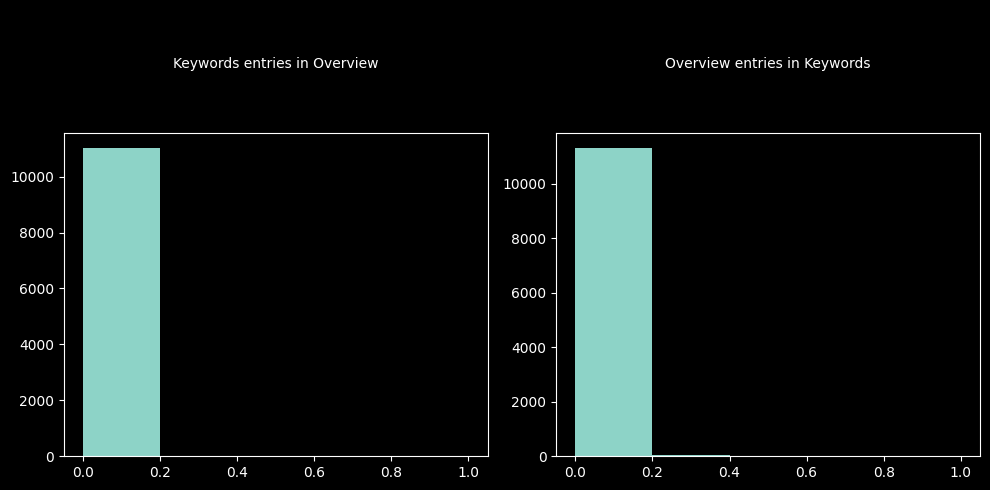

In [15]:
def find_coverage(words_collection_1, words_collection_2):
    ratios = []
    for words_1, words_2 in zip(words_collection_1, words_collection_2):
        covered = 0
        if not words_1:
            continue
        for word_2 in words_2:
            if word_2 in words_1:
                covered += 1
        ratios.append(covered/len(words_1))
    return ratios

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 5),
    gridspec_kw={'height_ratios': [1, 3]}  # top row smaller
)

axes[0,0].text(0.5, 0.5, 'Keywords entries in Overview', ha='center', va='center')
axes[0,0].axis('off')

axes[0,1].text(0.5, 0.5, 'Overview entries in Keywords', ha='center', va='center')
axes[0,1].axis('off')

axes[1,0].hist(find_coverage(overviews_separated, keywords_separated), bins=[0, 0.2, 0.4, 0.6, 0.8, 1])
axes[1,1].hist(find_coverage(keywords_separated, overviews_separated), bins=[0, 0.2, 0.4, 0.6, 0.8, 1])

fig.tight_layout()

Since I can't just treat Overview and Keywords as interchangeable, I will try combining them. I will than create two new lists- one filtering out words with less than 5 occurrences and one filtering out words with less than 10 occurrences. This reduces the size of the dataset from 48784 to 12171 and 7071. A significant decrease.

In [16]:
from collections import Counter

def get_word_counts_list(data):
    return Counter(word for sublist in data for word in sublist)

overview_keywords = overviews_separated + keywords_separated

overview_keywords_word_counts = get_word_counts_list(overview_keywords)

overview_keywords_word_counts_5 = {word: count for word, count in overview_keywords_word_counts.items() if count >= 5}

overview_keywords_word_counts_10 = {word: count for word, count in overview_keywords_word_counts.items() if count >= 10}

print('number of overall words: ' + str(len(overview_keywords_word_counts)))
print('number of words with at least 5 occurrences: ' + str(len(overview_keywords_word_counts_5)))
print('number of words with at least 10 occurrences: ' + str(len(overview_keywords_word_counts_10)))

overview_keywords_filtered_5 = [
    [word for word in sublist if word in overview_keywords_word_counts_5]
    for sublist in overview_keywords
]

overview_keywords_filtered_10 = [
    [word for word in sublist if word in overview_keywords_word_counts_10]
    for sublist in overview_keywords
]

number of overall words: 48784
number of words with at least 5 occurrences: 12171
number of words with at least 10 occurrences: 7071


Now I will try my first experiment with clustering. The algorithm searches for words with high levels of co-occurrence and groups them together. In the cells below I print out some of my results for different weight values. Unfortunately, there is no visible pattern in the words in each of earlier clusters. There is a pattern in the later clusters, but they are way too small to be usable.

In [17]:
from collections import defaultdict
import itertools
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities

def get_co_occurrence(input_words):
    co_occurrence = defaultdict(int)
    for word in input_words:
        if not word:
            continue
        for k1, k2 in itertools.combinations(set(word), 2):
            pair = tuple(sorted([k1, k2]))
            co_occurrence[pair] += 1
    return co_occurrence

def get_clusters(input_words, weight_val):
    co_occurrence = get_co_occurrence(input_words)
    G = nx.Graph()
    for (k1, k2), weight in co_occurrence.items():
        if weight >= weight_val:  # threshold (important!)
            G.add_edge(k1, k2, weight=weight)
    communities = greedy_modularity_communities(G)
    return [list(c) for c in communities]

In [18]:
clusters_overview_keywords_5_3 = get_clusters(overview_keywords_filtered_5, 3)
clusters_overview_keywords_10_3 = get_clusters(overview_keywords_filtered_10, 3)

KeyboardInterrupt: 

In [120]:
print(clusters_overview_keywords_5_3[0])
print('------------------------------------------------------------------------------------------')
print(clusters_overview_keywords_5_3[8])
print('------------------------------------------------------------------------------------------')
print(clusters_overview_keywords_10_3[0])
print('------------------------------------------------------------------------------------------')
print(clusters_overview_keywords_10_3[8])

['starvation', 'slapstick comedy', 'carry', 'christmas tree', 'inside', 'talking dog', 'surrounding', 'australia', 'prehistory', 'thomas', 'harbor', 'ostensibly', 'tear', '17th century', 'mock', 'crusade', 'arranged marriage', 'english countryside', 'treason', 'woods', 'prison guard', 'falsely', 'recession', 'commits', 'home invasion', 'wildlife', 'pre', 'agents', 'nottingham', 'homeland', 'magical creature', 'information', 'suspects', '2003', 'poirot', 'hands', 'ghostbuster', 'toughest', 'use', 'jin', 'magical', 'germans', 'mask', 'pharaoh', 'on the road', 'lego', 'invisibility', 'mafia', 'deception', 'perilous', 'trauma', 'consumption', 'aided', 'hostility', 'suspicion', 'war hero', 'steal', 'to', 'permanent', 'army', 'men', 'factory worker', 'bomb attack', 'assailant', 'nobility', 'kung fu', 'new england', 'north pole', 'telephone', 'stand', 'apache nation', 'sorceress', 'eyes', 'recruits', 'end of the world', 'alliances', 'alien technology', 'galaxy', 'alexander', 'trick', 'alive',

In [121]:
clusters_overview_keywords_5_7 = get_clusters(overview_keywords_filtered_5, 7)
clusters_overview_keywords_10_7 = get_clusters(overview_keywords_filtered_10, 7)

In [122]:
print(clusters_overview_keywords_5_7[0])
print('------------------------------------------------------------------------------------------')
print(clusters_overview_keywords_5_7[8])
print('------------------------------------------------------------------------------------------')
print(clusters_overview_keywords_10_7[0])
print('------------------------------------------------------------------------------------------')
print(clusters_overview_keywords_10_7[8])

['french', 'emotional', 'loving', 'showing', 'refuses', 'carry', 'revealed', 'appreciate', 'australia', 'invites', 'lake', 'transformed', 'tear', 'operation', 'wonder', 'illness', 'serve', 'fictional', 'maker', 'story', 'bored', 'realm', 'go', 'nazis', 'destined', 'lifestyle', 'awards', 'uncovers', 'despair', 'information', 'lucy', 'reputation', 'room', 'haddonfield', 'dad', 'locked', 'pick', 'now', 'existential', 'fishing', 'roman', 'answers', 'claim', 'richard', 'saves', 'amazing', 'steal', 'broken', 'videos', 'untold', 'happen', 'uptight', 'constantly', 'nation', 'personality', 'stand', 'eyes', '21st', 'soaked', 'balance', 'red', 'ballet', 'would', 'paths', 'contact', 'destiny', 'terrorists', 'violence', 'worldwide', 'budget', 'traumatic', 'renowned', 'excitement', 'intelligence', 'films', 'tribe', 'governments', 'used', 'gods', 'visuals', 'stone', 'teaching', 'cause', 'unknown', 'connection', 'terror', '2000s', 'kevin', 'battling', 'giant', 'exciting', 'obstacles', 'spanning', 'rel

In [123]:
clusters_overview_keywords_5_15 = get_clusters(overview_keywords_filtered_5, 15)
clusters_overview_keywords_10_15 = get_clusters(overview_keywords_filtered_10, 15)

In [124]:
print(clusters_overview_keywords_5_15[0])
print('------------------------------------------------------------------------------------------')
print(clusters_overview_keywords_5_15[8])
print('------------------------------------------------------------------------------------------')
print(clusters_overview_keywords_10_15[0])
print('------------------------------------------------------------------------------------------')
print(clusters_overview_keywords_10_15[8])

['win', 'french', 'emotional', 'loving', 'there', 'series', 'inside', 'short', 'forever', 'support', 'tour', 'france', 'story', 'movie', 'nazis', 'second', 'hunt', 'hope', 'tells', 'right', 'new', 'faces', 'prince', 'singer', 'is', 'farm', 'hands', 'feel', 'upside', 'rest', 'apart', 'dad', 'million', 'use', 'king', 'thinks', 'puts', 'existence', 'triangle', 'working', 'attempts', 'unlikely', 'classic', 'star', 'needs', 'feels', 'to', 'meeting', 'leaving', 'bad', 'can', 'uncover', 'london', 'eyes', 'experiences', 'faced', 'alive', 'writer', 'age', 'angeles', 'trip', 'hacker', 'protect', 'media', 'mr', 'secrets', 'budget', 'renowned', 'getting', 'films', 'purpose', 'book', 'used', 'unknown', 'offers', 'going', 'hopes', 'director', 'tale', 'obstacles', 'sam', 'relationships', 'bring', 'complete', 'south', 'kingdom', 'enemies', 'given', 'animated', 'show', 'turned', 'motion', 'explores', 'cinema', 'tragedy', 'night stand', 'spent', 'couple', 'follow', 'loosely', 'biggest', 'born', 'park', 

Maybe this dataset is too complicated- with 'transition' words like 'towards' and 'into' that don't give much insight into the actual content of a movie cluttering up the process. I will try the process again with just the keywords.

In [19]:
keywords_word_counts = get_word_counts_list(keywords_separated)

keywords_word_counts_5 = {word: count for word, count in keywords_word_counts.items() if count >= 5}

keywords_word_counts_10 = {word: count for word, count in keywords_word_counts.items() if count >= 10}

print('number of overall words: ' + str(len(keywords_word_counts)))
print('number of words with at least 5 occurrences: ' + str(len(keywords_word_counts_5)))
print('number of words with at least 10 occurrences: ' + str(len(keywords_word_counts_10)))

keywords_filtered_5 = [
    [word for word in sublist if word in keywords_word_counts_5]
    for sublist in keywords_separated
]

keywords_filtered_10 = [
    [word for word in sublist if word in keywords_word_counts_10]
    for sublist in keywords_separated
]

number of overall words: 17249
number of words with at least 5 occurrences: 3249
number of words with at least 10 occurrences: 1609


In [20]:
clusters_keywords_5_3 = get_clusters(keywords_filtered_5, 3)
clusters_keywords_10_3 = get_clusters(keywords_filtered_10, 3)

KeyboardInterrupt: 

Now, this actually IS giving meaningful clusters. The first one denotes Action/Adventure/Sci-Fi/Fantasy/Blockbuster movies. The second one denotes Crime/Dark-Drama/Noir movies, the third one denotes Coming-Of-Age/Family-Drama/Teen-Drama movies... (see PowerPoint for examples). The problem is that the categories quickly shrink in size. By the ninth one, we're only down to a few keywords denoting wresting movies.
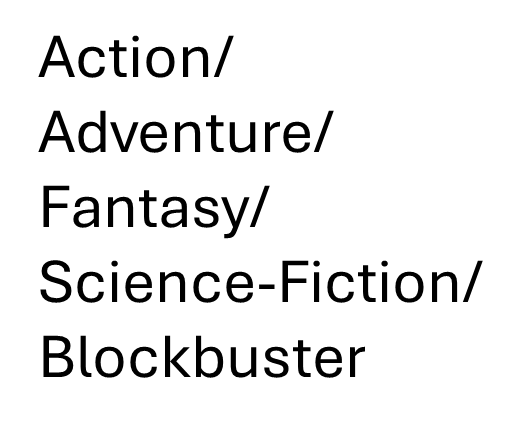
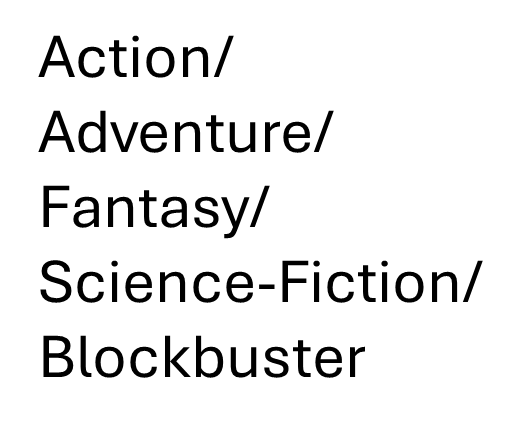
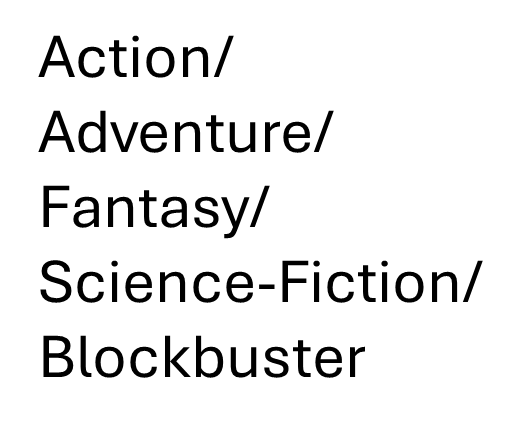

In [10]:
print(clusters_keywords_5_3[0])

['ambulance', 'yrf spy universe', 'sweden', 'matter of life and death', 'general', 'wuxia', 'riverboat', 'survival', 'space colony', 'australia', 'prehistory', 'skinny dipping', 'mission', 'war ship', 'scuba', '17th century', 'changing the past or future', 'france', 'english countryside', 'prison guard', 'atlantic ocean', 'new neighbor', 'crocodile', 'u.s. marshal', 'based on manga', 'prince', 'wealthy family', 'cruise', 'kaiju', 'magical creature', '18th century', 'deserted island', 'parallel world', 'duck', 'war', 'witchcraft', 'king', 'wolves', 'ancient evil', 'one against many', 'massacre', 'great wall of china', 'roman', 'millennium', 'invisibility', 'orcs', 'exotic island', 'soldier', 'dying and death', 'war hero', 'martial arts', 'commando', 'army', 'factory worker', 'sailing', 'live action anime', 'anti hero', 'kung fu', 'new england', 'mad scientist', 'apache nation', 'end of the world', '2030s', 'aftercreditsstinger', 'alien technology', 'epic', 'laser', 'galaxy', 'busan sout

In [11]:
print(clusters_keywords_5_3[1])

['motorcycle gang', 'dark comedy', 'boyfriend ex', 'new jersey', 'neighbor', 'mind game', 'lake', 'elevator', 'absurdism', 'insanity', 'voyeur', 'deadly', 'murder trial', 'bank robber', 'suicide', 'illness', 'treason', 'los angeles california', 'cannibal', 'woods', 'snuff', 'black humor', 'italy', 'briefcase', 'home invasion', 'jurors', 'ira (irish republican army)', 'summer camp', 'husband ex', 'yakuza', 'witness to murder', 'mask', 'childhood trauma', 'commune', 'on the road', 'extortion', 'saloon', 'mafia', 'prison', 'deception', 'drug trafficking', 'ku klux klan', 'trauma', 'russian mafia', 'suspicion', 'ambush', 'espionage', 'court', 'new orleans louisiana', 'bomb attack', 'the white house', 'telephone', 'trap', 'mute', 'racism', 'morgue', 'arson', 'cocaine', 'writer', 'attempted murder', 'judge', 'sexual obsession', 'porn actor', 'psychologist', 'italian american', 'remake', 'violence', 'usa president', 'criminal mastermind', 'slacker', 'drug rehabilitation', '1970s', 'cover', 'k

In [12]:
print(clusters_keywords_5_3[2])

['record producer', 'father daughter relationship', 'photography', 'child', 'marriage crisis', 'fashion designer', 'talking dog', 'group of friends', 'hustler', 'classroom', 'miracle', 'dentist', 'arranged marriage', 'sexuality', 'audition', 'hope', 'break', 'pop', 'alcohol', 'wildlife', 'pre', 'relationship problems', 'singer', 'christianity', 'farm', 'trainer', 'screenplay', 'baseball', 'teenage pregnancy', 'loss of loved one', 'car bomb', 'skyscraper', 'christian', 'beach', 'jazz', 'sultan', 'hostility', 'love at first sight', 'high school sports', 'tutor', 'guitar', 'horse race', 'judaism', 'ballet', 'escapade', 'talking cat', 'playwright', 'mother', 'mother son relationship', 'drinking', 'hamlet', 'songwriter', 'in the closet', 'womanizer', 'manhattan new york city', 'apartment building', 'unlikely friendship', 'poet', 'nervous breakdown', 'library', "rock 'n' roll", '2000s', 'teenage romance', 'celebrity', 'workers relationship', 'pedophile', 'lgbt', 'money laundering', 'mother d

In [13]:
print(clusters_keywords_5_3[3])

['religion and supernatural', 'monk', 'christ', 'exorcist', 'horror parody', 'exorcism', 'ghost child', 'doll', 'toy comes to life', 'vatican', 'séance', 'devil', 'spiritism', 'grim reaper', 'paranormal activity', 'spoof', 'puzzle box', 'satan', 'angel', 'paranormal investigation', 'paranormal phenomena', 'voodoo', 'killer doll', 'spirit', 'heaven', 'fake documentary', 'ghost', 'horror spoof', 'possession', 'orphanage', 'satanic cult', 'killer toys', 'ghostbuster', 'cannabis', 'hell', 'webcam', 'demonic possession', 'ouija board', 'anarchic comedy', 'crisis of faith', 'computer screen', 'satanic ritual', 'stoner movie', 'evil spirit', 'rome italy', 'buddy', 'haunting', 'possessed doll', 'evil doll', 'ritual', 'priest', 'medium', 'haunted house', 'facebook', 'catholicism', 'poltergeist', 'pot smoking', "devil's son", 'anti', 'paranormal', 'stoner', 'internet', 'found footage', 'catholic church', 'demon', 'afterlife']


In [14]:
print(clusters_keywords_5_3[4])

['atomic bomb', 'russian spy', 'disaster movie', 'catastrophe', 'dictatorship', 'ancient egypt', 'cairo', 'semitism', 'flood', 'political corruption', 'parachute', 'fascism', 'germany', 'pyramid', 'mummy', 'oklahoma', 'behind enemy lines', 'national socialism', 'war on terror', 'hijacking', 'swastika', 'flight', 'tomb', 'communist', 'nazi', 'evacuation', 'soviet military', 'cold war', 'natural disaster', 'united nations', 'soviet union', 'hurricane', 'tornado', 'stewardess', 'politician', 'nile', 'airplane accident', 'adolf hitler', 'panic', 'moses', 'terror cell', 'archaeologist', '9/11', 'egypt', 'dictator', 'tank', 'election campaign', 'deportation', 'treasure', 'tsunami', 'berlin germany', 'airplane', 'riddle', 'aviation', 'communism', 'treasure hunt', 'jew persecution', 'cataclysm', 'treasure map', 'archeology', 'tidal wave', 'volcanic eruption', 'flight attendant', 'helicopter crash', 'earthquake']


In [15]:
print(clusters_keywords_5_3[5])

['santa claus', 'apartheid', 'stuntman', 'race car driver', 'burglar', 'slapstick comedy', 'safari', 'africa', 'christmas eve', 'christmas tree', 'christmas party', 'severed head', 'shopping mall', 'hiking', 'animal', 'pain', 'big game hunter', 'winter', 'holiday season', 'zebra', 'mischievous child', 'decapitation', 'security guard', 'multiple storylines', 'antarctica', 'penguin', 'car race', 'reanimated corpse', 'racing', 'north pole', 'nature', 'hippopotamus', 'kenya', 'snowstorm', 'stunt', 'stupidity', 'south africa', 'office', 'colonialism', 'little boy', 'blizzard', 'zoo', 'talking animals', 'thanksgiving', 'department store', 'injury', 'power outage', 'street race', 'ecstasy', 'lemur', 'crisis', 'holiday', 'giraffe', 'snow', 'mountain climbing', 'climbing', 'human animal relationship', 'precocious child', 'himalaya mountain range', 'christmas']


In [16]:
print(clusters_keywords_5_3[6])

['con man', 'american dream', 'economics', 'capitalist', 'inspired by true story', 'capitalism', 'fraud', 'financial crisis', 'finances', 'wall street']


In [17]:
print(clusters_keywords_5_3[7])

['palestine', 'mossad', 'israeli conflict', 'hindu', 'israel', 'muslim', 'middle east', 'palestinian', 'islam']


In [18]:
print(clusters_keywords_5_3[8])

['wrestling', 'pro wrestling', 'female wrestler', 'wrestler', 'qoc', 'professional sports', 'wrestling match', 'female revolution', 'women fight']


Let's try K-Means-Clustering instead. Unfortunately, we can quickly see that this only makes the problem much worse.

In [21]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MultiLabelBinarizer

def k_means_cluster(inputs_words, k):
    mlb = MultiLabelBinarizer()
    X = mlb.fit_transform(inputs_words)
    X_keywords = X.T
    kmeans = KMeans(n_clusters=k)
    labels = kmeans.fit_predict(X_keywords)
    clusters = {}
    for keyword, label in zip(mlb.classes_, labels):
        clusters.setdefault(label, []).append(keyword)
    return clusters

def get_cluster_sizes_k_means(clusters):
    return [len(value) for key, value in clusters.items()]

In [22]:
print(get_cluster_sizes_k_means(k_means_cluster(keywords_separated, 5)))
print(get_cluster_sizes_k_means(k_means_cluster(keywords_separated, 10)))
print(get_cluster_sizes_k_means(k_means_cluster(keywords_separated, 20)))
print(get_cluster_sizes_k_means(k_means_cluster(keywords_separated, 50)))
print(get_cluster_sizes_k_means(k_means_cluster(keywords_separated, 100)))

C:\Users\yohan\PycharmProjects\GroupProject2\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\yohan\PycharmProjects\GroupProject2\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\yohan\PycharmProjects\GroupProject2\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\yohan\AppData\Local\Python\pythoncore-3.14-64\Lib\sub

[17245, 1, 1, 1, 1]



KeyboardInterrupt



We'll go back to the first clustering method. It isn't perfect, but maybe it can still help improve the algorithm. Here is a breakdown of the size distribution of the clusters when you input a number of different weight values.

In [31]:
def get_cluster_sizes_co_occurrence(clusters):
    return [len(entry) for entry in clusters]

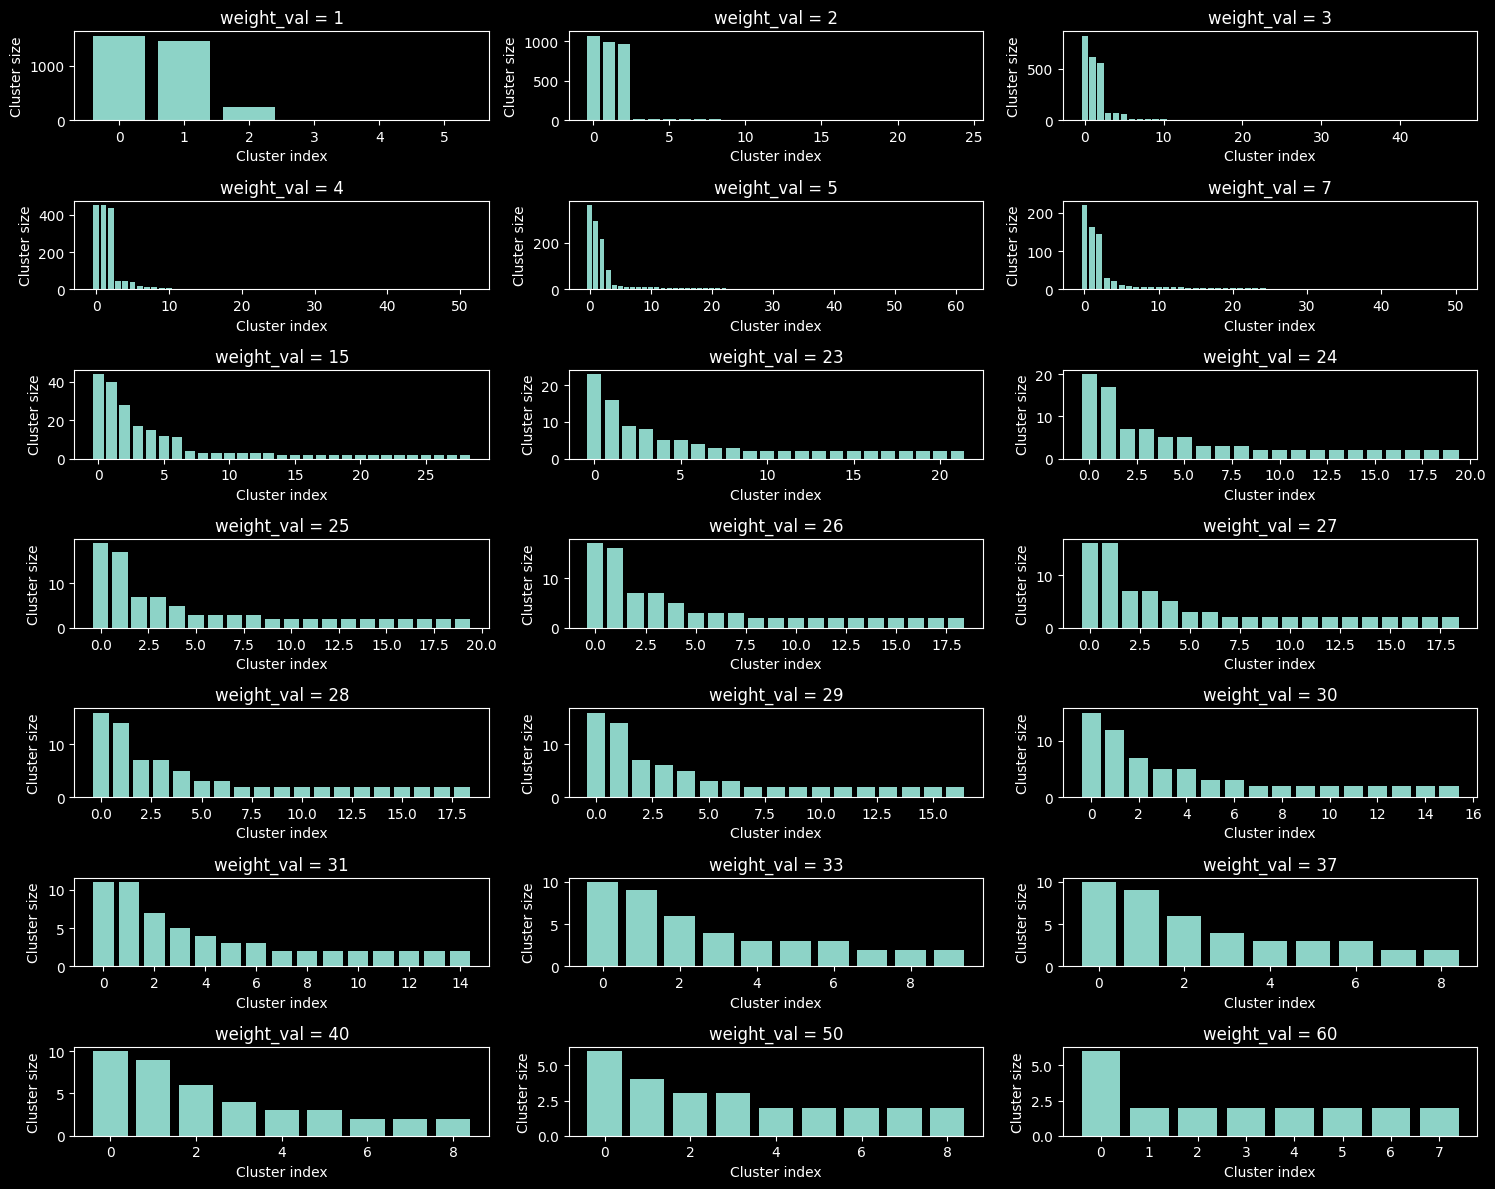

In [32]:
weight_vals = [1, 2, 3, 4, 5, 7, 15, 23, 24, 25, 26, 27, 28, 29, 30, 31, 33, 37, 40, 50, 60]

cluster_sets = [
    get_clusters(keywords_filtered_5, w)
    for w in weight_vals
]

cluster_sizes = [
    get_cluster_sizes_co_occurrence(entry)
    for entry in cluster_sets
]

# create 3x3 grid
fig, axes = plt.subplots(7, 3, figsize=(15, 12))
axes = axes.flatten()  # make indexing easier

for i, (sizes, w) in enumerate(zip(cluster_sizes, weight_vals)):
    ax = axes[i]

    # x = index of cluster, y = size
    ax.bar(range(len(sizes)), sizes)

    ax.set_title(f"weight_val = {w}")
    ax.set_xlabel("Cluster index")
    ax.set_ylabel("Cluster size")

plt.tight_layout()
plt.show()

Now let's test it out. As a control, I will first run a set without keywords columns and a set with the keywords processed through TF-IDF through an XGBoost model. Then I will loop through all the weight values for clustering and see if I can achieve a better test result.

In [24]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

df = pd.read_csv('MoviesDataset.csv', low_memory=False)

# Dropping Columns (some only for testing)
df.drop(columns=['title'], inplace=True)
df.drop(columns = ['overview'], inplace=True)
df.drop(columns=['production_companies'], inplace=True)
df.drop(columns = ['tagline'], inplace=True)
df.drop(columns=['vote_average'], inplace=True)
df.drop(columns=['vote_count'], inplace=True)
df.drop(columns=['popularity'], inplace=True)
df.drop(columns=['id'], inplace=True)
df.drop(columns=['merge_key'], inplace=True)
df.drop(columns=['record_origin'], inplace=True)
df.drop(columns=['poster_path'], inplace=True)
df.drop(columns=['backdrop_path'], inplace=True)
df.drop(columns=['recommendations'], inplace=True)
df.drop(columns=['adult'], inplace=True)
df.drop(columns=['homepage'], inplace=True)
df.drop(columns=['original_title'], inplace=True)
df.drop(columns=['actor_1', 'actor_2', 'actor_3', 'credits'], inplace=True)
df.drop(columns=['actor_1_tmdb_name', 'actor_2_tmdb_name', 'actor_3_tmdb_name'], inplace=True)
df.drop(columns=['imdb_id', 'actor_1_tmdb_id', 'actor_2_tmdb_id', 'actor_3_tmdb_id'], inplace=True)
df.drop(columns=['status'], inplace=True)
df.drop(columns=['production_countries'], inplace=True)
df.drop(columns=['spoken_languages'], inplace=True)

# Genres
df['genres'] = df['genres'].str.replace(r'\s*[-,]\s*', ',', regex=True)
df = df.join(df['genres'].str.get_dummies(sep=','))
df.drop(columns=['genres'], inplace=True)

# Original Language
language_dummies = df['original_language'].str.get_dummies().add_prefix('lang_')
df = df.join(language_dummies)
df.drop(columns=['original_language'], inplace=True)

# Release Date
df['release_date'] = pd.to_datetime(df['release_date'])
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month
df.drop(columns=['release_date'], inplace=True)
df['years_since_release']=2026-df['release_year']
df.drop(columns=['release_year'], inplace=True)

# MPAA Rating
mpaa_dummies = df['mpaa_rating'].str.get_dummies()
df = df.join(mpaa_dummies)
df.drop(columns=['mpaa_rating'], inplace=True)

# Apply Standard Scaling
numeric_cols = ['runtime', 'budget', 'revenue', 'years_since_release', 'actor_1_popularity', 'actor_2_popularity', 'actor_3_popularity', 'release_month']
df[numeric_cols] = StandardScaler().fit_transform(df[numeric_cols])

In [25]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

def get_r2(dataframe):
    X = dataframe.drop(columns=['revenue'])
    y = dataframe['revenue']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = XGBRegressor(n_estimators=50, objective="reg:squarederror", enable_categorical=True)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_train)
    r2_training = r2_score(y_train, y_pred)

    model = XGBRegressor(n_estimators=50, objective="reg:squarederror", enable_categorical=True)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2_testing = r2_score(y_test, y_pred)
    return [r2_training, r2_testing]

In [26]:
df_nokeywords = df.copy()
df_nokeywords.drop(columns=['keywords'], inplace=True)

r2s = get_r2(df_nokeywords)
print('No Keywords:')
print('Training R2: ' + str(r2s[0]))
print('Testing R2: ' + str(r2s[1]))

No Keywords:
Training R2: 0.8296040570043564
Testing R2: 0.4475244388469668


In [27]:
df_tfidf = df.copy()
split_series = df_tfidf['keywords'].fillna('').str.split('-')
dummies = (split_series.apply(lambda x: [i.strip() for i in x if i.strip() != '']).str.join('-').str.get_dummies(sep='-'))
top_1000 = (split_series.explode().str.strip().value_counts().head(1001).index)
top_1000 = top_1000.drop('')
dummies_top1000 = dummies[top_1000]
df_tfidf = df_tfidf.join(dummies_top1000)
df_tfidf.drop(columns=['keywords'], inplace=True)

r2s = get_r2(df_tfidf)
print('Keywords processed through TF-IDF:')
print('Training R2: ' + str(r2s[0]))
print('Testing R2: ' + str(r2s[1]))

Keywords processed through TF-IDF:
Training R2: 0.7813586637681127
Testing R2: 0.5107304784145128


In [33]:
training_r2 = []
testing_r2 = []

for cluster_set in cluster_sets:
    df_bins = df.copy()
    df_bins['keyword_set'] = df["keywords"].fillna('').str.split("-").apply(set)
    bins = [set(b) for b in cluster_set]
    for i, bin_words in enumerate(bins):
        df_bins[f"bin_{i}"] = df_bins["keyword_set"].apply(
            lambda words: len(words & bin_words)
        )
    df_bins.drop(columns=['keywords'], inplace=True)
    df_bins.drop(columns=['keyword_set'], inplace=True)
    r2s = get_r2(df_bins)
    training_r2.append(r2s[0])
    testing_r2.append(r2s[1])

Sadly, this experiment has not worked. The best test result I was able to get was almost exactly the same as the one achieved through TF-IDF. There appeared to be some potential around the 30 mark (which is why many test values are denly populated around there), but this unfortunately did not yield any useful results.

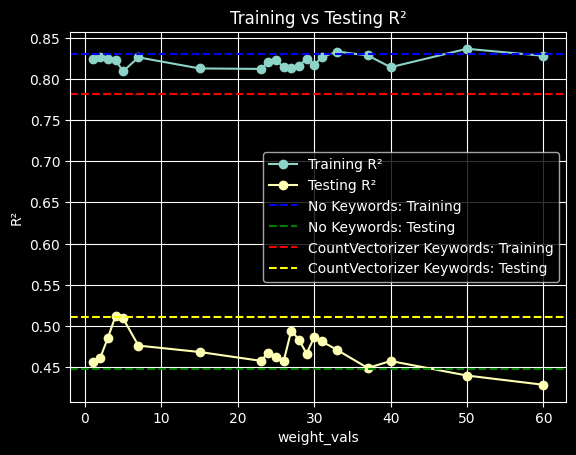

In [34]:
plt.figure()

# main lines
plt.plot(weight_vals, training_r2, marker='o', label='Training R²')
plt.plot(weight_vals, testing_r2, marker='o', label='Testing R²')

# horizontal reference lines
plt.axhline(0.8296040570043564, linestyle='--', label='No Keywords: Training', color = 'blue')
plt.axhline(0.4475244388469668, linestyle='--', label='No Keywords: Testing', color = 'green')
plt.axhline(0.7813586637681127, linestyle='--', label='CountVectorizer Keywords: Training', color = 'red')
plt.axhline(0.5107304784145128, linestyle='--', label='CountVectorizer Keywords: Testing', color = 'yellow')

plt.xlabel("weight_vals")
plt.ylabel("R²")
plt.title("Training vs Testing R²")

plt.legend()
plt.grid(True)